<a href="https://colab.research.google.com/github/OJB-Quantum/Cool-Mesh-Files/blob/main/Google%20Colab%20Notebooks/Two_Bar_Magnet_Geometries_Mesh_Generation_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2025)

Open Access (CC-BY-4.0)

In [1]:
# Colab cell 1: dependencies
!apt-get -qq update
!apt-get -qq install -y libglu1-mesa libgl1-mesa-glx

!pip -q install gmsh meshio numpy matplotlib

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package libglu1-mesa:amd64.
(Reading database ... 117528 files and directories currently installed.)
Preparing to unpack .../libglu1-mesa_9.0.2-1_amd64.deb ...
Unpacking libglu1-mesa:amd64 (9.0.2-1) ...
Setting up libglu1-mesa:amd64 (9.0.2-1) ...
Processing triggers for libc-bin (2.35-0ubuntu3.11) ...
/sbin/ldconfig.real: /usr/local/lib/libhwloc.so.15 is not a symbolic link

/sbin/ldconfig.real: /usr/local/lib/libur_loader.so.0 is not a symbolic link

/sbin/ldconfig.real: /usr/local/lib/libumf.so.1 is not a symbolic link

/sbin/ldconfig.real: /usr/local/lib/libtbb.so.12 is not a symbolic link

/sbin/ldconfig.real: /usr/local/lib/libtcm.so.1 is not a symbolic link

/sbin/ldconfig.real: /usr/local/lib/libur_adapter_level_zero_v2.so.0 is not a symbolic link

/sbin/ldconfi

In [2]:
# Colab cell 2: imports + Matplotlib configuration
from __future__ import annotations

from dataclasses import dataclass
from typing import Any, Dict, Iterable, List, Sequence, Tuple

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Line3DCollection

import gmsh


# Matplotlib "preview at 200 dpi using rcParams"
plt.rcParams.update({
    "figure.dpi": 200,
    "savefig.dpi": 200,
    "figure.figsize": (7.5, 6.0),
})

In [3]:
# Colab cell 3: control knobs (edit these first)
PARAMS: Dict[str, Any] = {
    # Geometry (meters)
    "Lm": 0.030,
    "Wm": 0.010,
    "Hm": 0.006,
    "gap": 0.005,
    "pad_x_mult": 2.0,
    "pad_y_mult": 3.0,
    "pad_z_mult": 3.0,

    # Mesh sizes (meters)
    "lc_edge_mag": 0.0006,
    "lc_surf_mag": 0.0012,
    "lc_edge_air": 0.0020,
    "lc_far": 0.0045,

    # Distance scales for Threshold ramps (meters)
    "d_edge_mag": 0.0030,
    "d_surf_mag": 0.0060,
    "d_edge_air": 0.0100,

    # Preview control
    "preview_max_faces": 25000,

    # Logging
    "gmsh_verbosity": 2,
}

In [4]:
# Colab cell 4: geometry construction utilities (volume identification)
def _bbox_eps(scale: float) -> float:
    """
    Geometry queries after boolean ops need a tolerance that is large enough to survive
    BRep/boolean numerical noise, but still small relative to your model.
    """
    # For meter-scale models this is microns to tens-of-microns; for mm-scale models, it stays tiny.
    return max(1e-9, 1e-6 * float(scale))


def _unique_dimtags(dimtags):
    seen = set()
    out = []
    for dim, tag in dimtags:
        key = (int(dim), int(tag))
        if key not in seen:
            out.append((int(dim), int(tag)))
            seen.add(key)
    return out


def _centroid_distance(a, b) -> float:
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    return float(np.linalg.norm(a - b))


def build_two_magnets_with_air(params: Dict[str, Any]) -> Dict[str, Any]:
    """
    Build two bar magnets inside an air box, then fragment to enforce conformal interfaces.
    This version identifies output magnet volumes primarily via occ.fragment()'s out_map.
    Falls back to center-of-mass classification if needed.
    """
    Lm = float(params["Lm"])
    Wm = float(params["Wm"])
    Hm = float(params["Hm"])
    gap = float(params["gap"])

    pad_x = float(params["pad_x_mult"]) * Lm
    pad_y = float(params["pad_y_mult"]) * Wm
    pad_z = float(params["pad_z_mult"]) * Hm

    # Magnet 1 spans x in [-(gap/2 + Lm), -gap/2]
    x1 = -0.5 * gap - Lm
    y1 = -0.5 * Wm
    z1 = -0.5 * Hm

    # Magnet 2 spans x in [gap/2, gap/2 + Lm]
    x2 = 0.5 * gap
    y2 = y1
    z2 = z1

    # Air extents
    mag_xmin = x1
    mag_xmax = x2 + Lm
    mag_ymin = y1
    mag_ymax = y1 + Wm
    mag_zmin = z1
    mag_zmax = z1 + Hm

    air_xmin = mag_xmin - pad_x
    air_xmax = mag_xmax + pad_x
    air_ymin = mag_ymin - pad_y
    air_ymax = mag_ymax + pad_y
    air_zmin = mag_zmin - pad_z
    air_zmax = mag_zmax + pad_z

    air_dx = air_xmax - air_xmin
    air_dy = air_ymax - air_ymin
    air_dz = air_zmax - air_zmin

    # Create volumes (OpenCASCADE kernel)
    air_tag = gmsh.model.occ.addBox(air_xmin, air_ymin, air_zmin, air_dx, air_dy, air_dz)
    mag1_tag = gmsh.model.occ.addBox(x1, y1, z1, Lm, Wm, Hm)
    mag2_tag = gmsh.model.occ.addBox(x2, y2, z2, Lm, Wm, Hm)

    # Fragment => conformal interfaces between air and magnets
    out_dimtags, out_map = gmsh.model.occ.fragment(
        objectDimTags=[(3, air_tag)],
        toolDimTags=[(3, mag1_tag), (3, mag2_tag)],
        removeObject=True,
        removeTool=True,
    )
    gmsh.model.occ.synchronize()

    # Primary: use the fragment mapping (most robust).
    # Convention: out_map[0] corresponds to objectDimTags[0] (air),
    # out_map[1] corresponds to toolDimTags[0] (magnet 1),
    # out_map[2] corresponds to toolDimTags[1] (magnet 2).
    mag1_vols = []
    mag2_vols = []
    air_vols = []

    try:
        air_vols = [dt for dt in out_map[0] if int(dt[0]) == 3]
        mag1_vols = [dt for dt in out_map[1] if int(dt[0]) == 3]
        mag2_vols = [dt for dt in out_map[2] if int(dt[0]) == 3]
        air_vols = _unique_dimtags(air_vols)
        mag1_vols = _unique_dimtags(mag1_vols)
        mag2_vols = _unique_dimtags(mag2_vols)
    except Exception:
        # If out_map structure differs (version quirks), we will fall back below.
        air_vols = []
        mag1_vols = []
        mag2_vols = []

    # Fallback: classify by center of mass proximity to expected magnet centers.
    if len(mag1_vols) < 1 or len(mag2_vols) < 1:
        all_vols = _unique_dimtags(gmsh.model.getEntities(dim=3))

        expected_c1 = (x1 + 0.5 * Lm, y1 + 0.5 * Wm, z1 + 0.5 * Hm)
        expected_c2 = (x2 + 0.5 * Lm, y2 + 0.5 * Wm, z2 + 0.5 * Hm)

        # Compute centers for each volume
        centers = []
        for dim, tag in all_vols:
            cx, cy, cz = gmsh.model.occ.getCenterOfMass(dim, tag)
            centers.append(((dim, tag), (cx, cy, cz)))

        # Choose nearest volume to each expected center, ensuring they are distinct
        best1 = min(centers, key=lambda it: _centroid_distance(it[1], expected_c1))[0]
        centers_remaining = [it for it in centers if it[0] != best1]
        best2 = min(centers_remaining, key=lambda it: _centroid_distance(it[1], expected_c2))[0]

        mag1_vols = [best1]
        mag2_vols = [best2]

        mag_set = {tuple(best1), tuple(best2)}
        air_vols = [vt for vt in all_vols if tuple(vt) not in mag_set]

    if len(mag1_vols) < 1 or len(mag2_vols) < 1 or len(air_vols) < 1:
        raise RuntimeError(
            "Volume identification failed even after fallback. "
            f"mag1={mag1_vols}, mag2={mag2_vols}, air={air_vols}"
        )

    # Physical groups (group all volumes for each region, just in case a boolean split occurs)
    phys_mag1 = gmsh.model.addPhysicalGroup(3, [t for _, t in mag1_vols])
    gmsh.model.setPhysicalName(3, phys_mag1, "MAGNET_1")

    phys_mag2 = gmsh.model.addPhysicalGroup(3, [t for _, t in mag2_vols])
    gmsh.model.setPhysicalName(3, phys_mag2, "MAGNET_2")

    phys_air = gmsh.model.addPhysicalGroup(3, [t for _, t in air_vols])
    gmsh.model.setPhysicalName(3, phys_air, "AIR")

    return {
        "mag1_vol": mag1_vols,
        "mag2_vol": mag2_vols,
        "air_vol": air_vols,
        "mag1_box": (x1, y1, z1, x1 + Lm, y1 + Wm, z1 + Hm),
        "mag2_box": (x2, y2, z2, x2 + Lm, y2 + Wm, z2 + Hm),
        "air_box": (air_xmin, air_ymin, air_zmin, air_xmax, air_ymax, air_zmax),
    }

In [5]:
# Colab cell 5: mesh size field construction (Distance + Threshold + Min)
def _boundary_surfaces_of_volumes(vol_dimtags: Sequence[Tuple[int, int]]) -> List[int]:
    bnd = gmsh.model.getBoundary(list(vol_dimtags), oriented=False, recursive=False)
    return [tag for dim, tag in bnd if dim == 2]


def _boundary_curves_of_surfaces(surf_dimtags: Sequence[Tuple[int, int]]) -> List[int]:
    bnd = gmsh.model.getBoundary(list(surf_dimtags), oriented=False, recursive=False)
    return [tag for dim, tag in bnd if dim == 1]


def _outer_air_box_surfaces(air_box: Tuple[float, float, float, float, float, float]) -> List[int]:
    """
    Collect the 6 outer faces of the air box using bounding-box queries near each plane.
    This avoids accidentally capturing magnet-air interface surfaces.
    """
    xmin, ymin, zmin, xmax, ymax, zmax = air_box
    scale = max(xmax - xmin, ymax - ymin, zmax - zmin)
    eps = _bbox_eps(scale)

    surf_sets: List[List[Tuple[int, int]]] = []
    # x = xmin and x = xmax
    surf_sets.append(gmsh.model.getEntitiesInBoundingBox(xmin - eps, ymin - eps, zmin - eps, xmin + eps, ymax + eps, zmax + eps, dim=2))
    surf_sets.append(gmsh.model.getEntitiesInBoundingBox(xmax - eps, ymin - eps, zmin - eps, xmax + eps, ymax + eps, zmax + eps, dim=2))
    # y = ymin and y = ymax
    surf_sets.append(gmsh.model.getEntitiesInBoundingBox(xmin - eps, ymin - eps, zmin - eps, xmax + eps, ymin + eps, zmax + eps, dim=2))
    surf_sets.append(gmsh.model.getEntitiesInBoundingBox(xmin - eps, ymax - eps, zmin - eps, xmax + eps, ymax + eps, zmax + eps, dim=2))
    # z = zmin and z = zmax
    surf_sets.append(gmsh.model.getEntitiesInBoundingBox(xmin - eps, ymin - eps, zmin - eps, xmax + eps, ymax + eps, zmin + eps, dim=2))
    surf_sets.append(gmsh.model.getEntitiesInBoundingBox(xmin - eps, ymin - eps, zmax - eps, xmax + eps, ymax + eps, zmax + eps, dim=2))

    out: List[int] = []
    for s in surf_sets:
        for dim, tag in _unique_dimtags(s):
            if dim == 2:
                out.append(int(tag))
    return sorted(set(out))


def add_edge_and_surface_refinement_fields(
    params: Dict[str, Any],
    mag_vols: Sequence[Tuple[int, int]],
    air_box: Tuple[float, float, float, float, float, float],
) -> int:
    """
    Build background mesh size field:
      - very fine near magnet edges (curves)
      - moderately fine near magnet surfaces
      - optionally refined near outer air-box edges
    Returns the background field tag.
    """
    lc_edge_mag = float(params["lc_edge_mag"])
    lc_surf_mag = float(params["lc_surf_mag"])
    lc_edge_air = float(params["lc_edge_air"])
    lc_far = float(params["lc_far"])

    d_edge_mag = float(params["d_edge_mag"])
    d_surf_mag = float(params["d_surf_mag"])
    d_edge_air = float(params["d_edge_air"])

    # Magnet boundary surfaces + boundary curves (edges)
    mag_surfaces = _boundary_surfaces_of_volumes(mag_vols)
    mag_surface_dimtags = [(2, s) for s in mag_surfaces]
    mag_curves = _boundary_curves_of_surfaces(mag_surface_dimtags)

    # Air-box outer surfaces and their curves (outer edges)
    air_outer_surfaces = _outer_air_box_surfaces(air_box)
    air_outer_surface_dimtags = [(2, s) for s in air_outer_surfaces]
    air_outer_curves = _boundary_curves_of_surfaces(air_outer_surface_dimtags)

    # ---- Field 1/2: Magnet edges (curves) -> Distance -> Threshold
    f_dist_edge_mag = gmsh.model.mesh.field.add("Distance")
    gmsh.model.mesh.field.setNumbers(f_dist_edge_mag, "CurvesList", mag_curves)
    gmsh.model.mesh.field.setNumber(f_dist_edge_mag, "Sampling", 50)

    f_thr_edge_mag = gmsh.model.mesh.field.add("Threshold")
    gmsh.model.mesh.field.setNumber(f_thr_edge_mag, "InField", f_dist_edge_mag)
    gmsh.model.mesh.field.setNumber(f_thr_edge_mag, "SizeMin", lc_edge_mag)
    gmsh.model.mesh.field.setNumber(f_thr_edge_mag, "SizeMax", lc_far)
    gmsh.model.mesh.field.setNumber(f_thr_edge_mag, "DistMin", 0.0)
    gmsh.model.mesh.field.setNumber(f_thr_edge_mag, "DistMax", d_edge_mag)

    # ---- Field 3/4: Magnet surfaces -> Distance -> Threshold
    f_dist_surf_mag = gmsh.model.mesh.field.add("Distance")
    gmsh.model.mesh.field.setNumbers(f_dist_surf_mag, "SurfacesList", mag_surfaces)
    gmsh.model.mesh.field.setNumber(f_dist_surf_mag, "Sampling", 30)

    f_thr_surf_mag = gmsh.model.mesh.field.add("Threshold")
    gmsh.model.mesh.field.setNumber(f_thr_surf_mag, "InField", f_dist_surf_mag)
    gmsh.model.mesh.field.setNumber(f_thr_surf_mag, "SizeMin", lc_surf_mag)
    gmsh.model.mesh.field.setNumber(f_thr_surf_mag, "SizeMax", lc_far)
    gmsh.model.mesh.field.setNumber(f_thr_surf_mag, "DistMin", 0.0)
    gmsh.model.mesh.field.setNumber(f_thr_surf_mag, "DistMax", d_surf_mag)

    # ---- Field 5/6: Outer air-box edges -> Distance -> Threshold (optional but enabled by default)
    f_dist_edge_air = gmsh.model.mesh.field.add("Distance")
    gmsh.model.mesh.field.setNumbers(f_dist_edge_air, "CurvesList", air_outer_curves)
    gmsh.model.mesh.field.setNumber(f_dist_edge_air, "Sampling", 30)

    f_thr_edge_air = gmsh.model.mesh.field.add("Threshold")
    gmsh.model.mesh.field.setNumber(f_thr_edge_air, "InField", f_dist_edge_air)
    gmsh.model.mesh.field.setNumber(f_thr_edge_air, "SizeMin", lc_edge_air)
    gmsh.model.mesh.field.setNumber(f_thr_edge_air, "SizeMax", lc_far)
    gmsh.model.mesh.field.setNumber(f_thr_edge_air, "DistMin", 0.0)
    gmsh.model.mesh.field.setNumber(f_thr_edge_air, "DistMax", d_edge_air)

    # ---- Combine: local min across all refinement requests
    f_min = gmsh.model.mesh.field.add("Min")
    gmsh.model.mesh.field.setNumbers(f_min, "FieldsList", [f_thr_edge_mag, f_thr_surf_mag, f_thr_edge_air])

    gmsh.model.mesh.field.setAsBackgroundMesh(f_min)

    # Also clamp global mesh size range (helps prevent accidental extremes)
    gmsh.option.setNumber("Mesh.MeshSizeMin", min(lc_edge_mag, lc_surf_mag, lc_edge_air, lc_far))
    gmsh.option.setNumber("Mesh.MeshSizeMax", max(lc_edge_mag, lc_surf_mag, lc_edge_air, lc_far))

    return f_min

In [6]:
# Colab cell 6: generate the 3D mesh and export
def generate_mesh(params: Dict[str, Any], msh_path: str = "two_magnets_air_refined.msh") -> Dict[str, Any]:
    gmsh.initialize()
    try:
        gmsh.model.add("two_magnets_with_air")

        gmsh.option.setNumber("General.Terminal", 1)
        gmsh.option.setNumber("General.Verbosity", float(params["gmsh_verbosity"]))

        # When using an explicit background size field, it is often cleaner to disable
        # size inference from points/curvature/boundary extension.
        gmsh.option.setNumber("Mesh.MeshSizeExtendFromBoundary", 0)
        gmsh.option.setNumber("Mesh.MeshSizeFromPoints", 0)
        gmsh.option.setNumber("Mesh.MeshSizeFromCurvature", 0)

        # Robust choice when size varies a lot
        gmsh.option.setNumber("Mesh.Algorithm", 5)       # 2D: Delaunay
        gmsh.option.setNumber("Mesh.Algorithm3D", 1)     # 3D: Delaunay

        built = build_two_magnets_with_air(params)

        # Add mesh sizing field
        mag_vols = built["mag1_vol"] + built["mag2_vol"]
        _ = add_edge_and_surface_refinement_fields(params, mag_vols, built["air_box"])

        # Generate tetrahedral mesh
        gmsh.model.mesh.generate(3)

        # Write mesh
        gmsh.write(msh_path)

        return built
    finally:
        # Always finalize, even if something above throws.
        gmsh.finalize()


BUILT = generate_mesh(PARAMS, msh_path="two_magnets_air_refined.msh")
print("Wrote:", "two_magnets_air_refined.msh")
print("Magnet1 bbox:", BUILT["mag1_box"])
print("Magnet2 bbox:", BUILT["mag2_box"])
print("Air bbox:", BUILT["air_box"])
print("Magnet1 volume dimtags:", BUILT["mag1_vol"])
print("Magnet2 volume dimtags:", BUILT["mag2_vol"])
print("Air volume dimtags:", BUILT["air_vol"])

Wrote: two_magnets_air_refined.msh
Magnet1 bbox: (-0.0325, -0.005, -0.003, -0.0025000000000000022, 0.005, 0.003)
Magnet2 bbox: (0.0025, -0.005, -0.003, 0.0325, 0.005, 0.003)
Air bbox: (-0.0925, -0.034999999999999996, -0.021, 0.0925, 0.034999999999999996, 0.021)
Magnet1 volume dimtags: [(3, 2)]
Magnet2 volume dimtags: [(3, 3)]
Air volume dimtags: [(3, 4), (3, 2), (3, 3)]


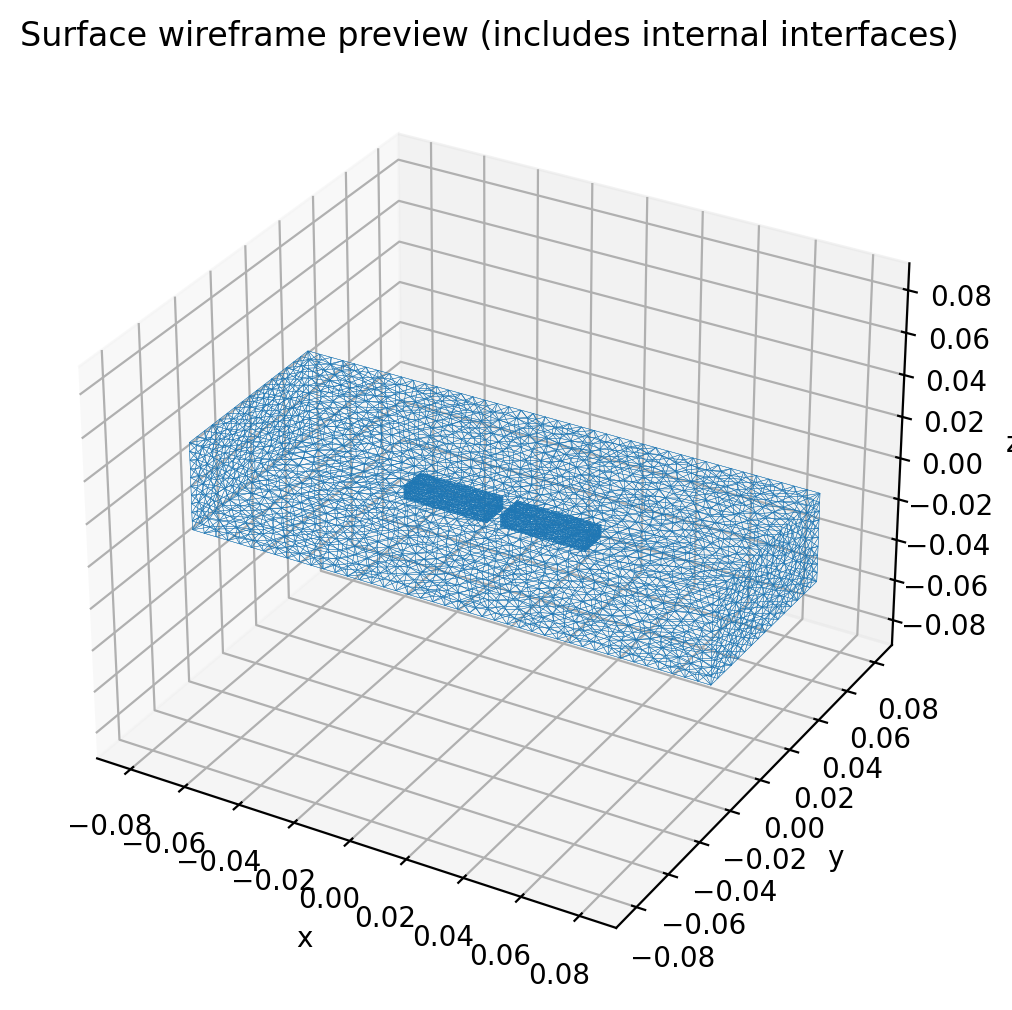

In [8]:
# Colab cell 7: surface/interface preview with Matplotlib
from typing import Any, Dict, List, Tuple

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Line3DCollection

import gmsh


def preview_msh_surface_wireframe(
    params: Dict[str, Any],
    msh_path: str,
    include_internal_interfaces: bool = True,
    seed: int = 0,
    linewidth: float = 0.15,
) -> None:
    """
    Preview a Gmsh .msh in Matplotlib by plotting a wireframe of triangular faces.

    Strategy:
      1) Try to read explicit 2D surface elements (dim=2). If present, use them.
      2) If absent, derive triangles from 3D tetrahedra:
         - If include_internal_interfaces=True: compute boundary faces per volume entity
           and union them (this includes internal interfaces like magnet-air).
         - Else: compute only the external boundary of the entire mesh.

    Args:
      params: Notebook control knobs dict; must include "preview_max_faces".
      msh_path: Path to .msh file.
      include_internal_interfaces: If True, show internal region interfaces too.
      seed: Random seed for deterministic downsampling.
      linewidth: Wireframe line width.
    """
    preview_max_faces = int(params.get("preview_max_faces", 25000))

    # Initialize/finalize safely even if previous cells crashed.
    did_init = False
    try:
        is_init = getattr(gmsh, "isInitialized", None)
        if callable(is_init):
            if not gmsh.isInitialized():
                gmsh.initialize()
                did_init = True
        else:
            gmsh.initialize()
            did_init = True

        gmsh.option.setNumber("General.Terminal", 1)
        gmsh.open(msh_path)

        # --- Nodes (tag -> xyz)
        node_tags, node_coords, _ = gmsh.model.mesh.getNodes()
        node_tags = np.asarray(node_tags, dtype=np.int64)
        node_coords = np.asarray(node_coords, dtype=np.float64).reshape(-1, 3)

        order = np.argsort(node_tags)
        node_tags_sorted = node_tags[order]
        node_coords_sorted = node_coords[order]

        def coords_for_tags(tags: np.ndarray) -> np.ndarray:
            """Vectorized tag->xyz lookup with validation."""
            tags = np.asarray(tags, dtype=np.int64)
            idx = np.searchsorted(node_tags_sorted, tags)
            if np.any(idx < 0) or np.any(idx >= node_tags_sorted.shape[0]):
                raise RuntimeError("Node tag lookup failed: out-of-range index computed.")
            if np.any(node_tags_sorted[idx] != tags):
                bad = tags[node_tags_sorted[idx] != tags][:10]
                raise RuntimeError(
                    "Node tag lookup failed: some node tags were not found. "
                    f"Example missing tags: {bad}"
                )
            return node_coords_sorted[idx]

        # --- Attempt A: explicit surface elements
        tri_faces = _try_get_triangles_from_dim2_elements()

        # --- Attempt B: derive faces from tetrahedra if needed
        if tri_faces is None or tri_faces.size == 0:
            tri_faces = _derive_triangles_from_dim3_tets(
                include_internal_interfaces=include_internal_interfaces
            )

        if tri_faces is None or tri_faces.size == 0:
            raise RuntimeError(
                "Could not find any triangles for preview. "
                "Your mesh file may not contain tetrahedra, or it may be missing entities."
            )

        # Downsample for plotting (faces -> segments grows quickly)
        n_faces = tri_faces.shape[0]
        if n_faces > preview_max_faces:
            rng = np.random.default_rng(seed)
            keep = rng.choice(n_faces, size=preview_max_faces, replace=False)
            tri_faces = tri_faces[keep, :]

        # Build wireframe segments from triangles
        p0 = coords_for_tags(tri_faces[:, 0])
        p1 = coords_for_tags(tri_faces[:, 1])
        p2 = coords_for_tags(tri_faces[:, 2])

        segs = np.concatenate(
            [
                np.stack([p0, p1], axis=1),
                np.stack([p1, p2], axis=1),
                np.stack([p2, p0], axis=1),
            ],
            axis=0,
        )

    finally:
        # Always finalize if we initialized here.
        if did_init:
            try:
                gmsh.finalize()
            except Exception:
                pass

    # Plot (Matplotlib rcParams already set to 200 DPI in your earlier cell)
    fig = plt.figure()
    ax = fig.add_subplot(111, projection="3d")
    ax.add_collection3d(Line3DCollection(segs, linewidths=float(linewidth)))

    # Equal-ish axis scaling based on full node set (not just downsample)
    mins = node_coords.min(axis=0)
    maxs = node_coords.max(axis=0)
    center = 0.5 * (mins + maxs)
    span = float((maxs - mins).max())

    ax.set_xlim(center[0] - 0.5 * span, center[0] + 0.5 * span)
    ax.set_ylim(center[1] - 0.5 * span, center[1] + 0.5 * span)
    ax.set_zlim(center[2] - 0.5 * span, center[2] + 0.5 * span)

    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")
    title = "Surface wireframe preview"
    if include_internal_interfaces:
        title += " (includes internal interfaces)"
    else:
        title += " (external boundary only)"
    ax.set_title(title)
    plt.show()


def _try_get_triangles_from_dim2_elements() -> np.ndarray | None:
    """
    Try to extract triangles from explicit 2D elements (dim=2) in the loaded model.
    Returns (F,3) array of node tags, or None/empty if not available.
    """
    elem_types, _, elem_node_tags = gmsh.model.mesh.getElements(dim=2)
    if elem_types is None or len(elem_types) == 0:
        return None

    faces: List[np.ndarray] = []
    for etype, enodes in zip(elem_types, elem_node_tags):
        name, dim, order_e, num_nodes, _, num_primary = gmsh.model.mesh.getElementProperties(etype)
        enodes = np.asarray(enodes, dtype=np.int64).reshape(-1, num_nodes)
        prim = enodes[:, :num_primary]

        if num_primary == 3:
            faces.append(prim)
        elif num_primary == 4:
            # Quad -> two triangles
            faces.append(prim[:, [0, 1, 2]])
            faces.append(prim[:, [0, 2, 3]])
        else:
            continue

    if not faces:
        return None

    tri_faces = np.vstack(faces)
    # Normalize orientation-insensitive representation
    tri_faces = np.unique(np.sort(tri_faces, axis=1), axis=0)
    return tri_faces


def _derive_triangles_from_dim3_tets(include_internal_interfaces: bool) -> np.ndarray:
    """
    Derive triangular faces from tetrahedra in the loaded model.

    If include_internal_interfaces is True:
      - For each volume entity, find faces on that volume's boundary (count==1 within that volume),
        then union across volumes. This includes internal interfaces like magnet-air.

    If False:
      - Find faces on the external boundary of the entire tetra set (count==1 globally).
    """
    def tet_faces(tets: np.ndarray) -> np.ndarray:
        # tets: (Nt,4) of node tags
        return np.concatenate(
            [
                tets[:, [0, 1, 2]],
                tets[:, [0, 1, 3]],
                tets[:, [0, 2, 3]],
                tets[:, [1, 2, 3]],
            ],
            axis=0,
        )

    def boundary_faces_from_tets(tets: np.ndarray) -> np.ndarray:
        f = tet_faces(tets)
        f = np.sort(f, axis=1)
        uniq, counts = np.unique(f, axis=0, return_counts=True)
        return uniq[counts == 1]

    if include_internal_interfaces:
        vol_entities: List[Tuple[int, int]] = gmsh.model.getEntities(dim=3)
        all_bnd: List[np.ndarray] = []

        for dim, vtag in vol_entities:
            etypes, _, enodes_list = gmsh.model.mesh.getElements(dim=3, tag=vtag)
            if etypes is None or len(etypes) == 0:
                continue

            tets_local: List[np.ndarray] = []
            for etype, enodes in zip(etypes, enodes_list):
                name, dim_e, order_e, num_nodes, _, num_primary = gmsh.model.mesh.getElementProperties(etype)
                enodes = np.asarray(enodes, dtype=np.int64).reshape(-1, num_nodes)
                prim = enodes[:, :num_primary]

                # Tetrahedron corner node count is 4 (including higher-order tets where num_nodes>4).
                if num_primary == 4:
                    tets_local.append(prim)

            if tets_local:
                tets_local = np.vstack(tets_local)
                all_bnd.append(boundary_faces_from_tets(tets_local))

        if not all_bnd:
            return np.empty((0, 3), dtype=np.int64)

        tri = np.vstack(all_bnd)
        tri = np.unique(tri, axis=0)
        return tri

    # External boundary only (global)
    etypes, _, enodes_list = gmsh.model.mesh.getElements(dim=3)
    if etypes is None or len(etypes) == 0:
        return np.empty((0, 3), dtype=np.int64)

    tets: List[np.ndarray] = []
    for etype, enodes in zip(etypes, enodes_list):
        name, dim_e, order_e, num_nodes, _, num_primary = gmsh.model.mesh.getElementProperties(etype)
        enodes = np.asarray(enodes, dtype=np.int64).reshape(-1, num_nodes)
        prim = enodes[:, :num_primary]
        if num_primary == 4:
            tets.append(prim)

    if not tets:
        return np.empty((0, 3), dtype=np.int64)

    tets = np.vstack(tets)
    tri = boundary_faces_from_tets(tets)
    tri = np.unique(tri, axis=0)
    return tri


# Run the preview
preview_msh_surface_wireframe(PARAMS, "two_magnets_air_refined.msh", include_internal_interfaces=True)

Now it is possible to go the files on the left tab and download the (.msh) file.